In [58]:
# Аугментации
from torchvision.transforms.v2 import RandomRotation, RandomPhotometricDistort, \
RandomHorizontalFlip, RandomVerticalFlip, Compose, Resize
from torchvision.transforms import ToTensor, Normalize

# Загрузка датасета
from torchvision.datasets import ImageFolder
from torch.utils.data import random_split, Dataset, DataLoader
import torch

# Модель
from torchsummary import summary
from torchvision.models import mobilenet_v3_small
import torch.nn as nn

# Обучение
import torch.optim as optim
from tqdm import tqdm

# Валидация
from sklearn.metrics import classification_report

# Визуализация
from matplotlib import pyplot as plt

In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


# Подготовка датасета

Используемый датасет: https://www.kaggle.com/datasets/masouduut94/digikala-color-classification

In [32]:
dataset_path = 'data/digikala'
dataset = ImageFolder(dataset_path)
train_dataset, val_dataset = random_split(dataset, [0.8, 0.2])

brown
blue
pink
brown
pink
yellow
purple
red
white
red


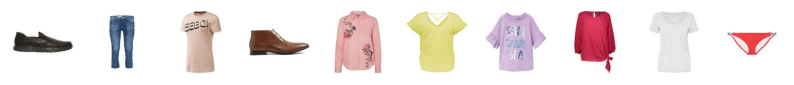

In [33]:
# Визуализация датасета до трансформаций
fig = plt.figure(figsize=(10,5))
for index in range (1, 11):
    image, label = train_dataset[index]
    print(dataset.classes[label])
    plt.subplot(1, 10, index)
    plt.imshow(image)
    plt.axis('off')

In [34]:
# Аугментации
train_transforms = Compose([
    Resize((224, 224)),
    ToTensor(),
    Normalize((0.5), (0.5)),
    RandomHorizontalFlip(p=0.2),
    RandomVerticalFlip(p=0.2),
    RandomRotation([-5, 5], fill=255.)
])

val_transforms = Compose([
    Resize((224, 224)),
    ToTensor(),
    Normalize((0.5), (0.5))
]) 

In [35]:
class TransformDataset(Dataset):
  def __init__(self, dataset, transforms):
    super(TransformDataset, self).__init__()
    self.dataset = dataset
    self.transforms = transforms

  def __len__(self):
    return len(self.dataset)

  def __getitem__(self, idx):
    x, y = self.dataset[idx]
    return self.transforms(x), y

In [36]:
train_dataset = TransformDataset(train_dataset, train_transforms)
val_dataset = TransformDataset(val_dataset, val_transforms) 

In [37]:
batch_size = 32

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

In [38]:
print("Количество изображений в train:", len(train_dataset))
print("Количество изображений в val:", len(val_dataset))
print("Список классов:", dataset.classes) 

Количество изображений в train: 4992
Количество изображений в val: 1247
Список классов: ['black', 'blue', 'brown', 'green', 'grey', 'orange', 'pink', 'purple', 'red', 'silver', 'white', 'yellow']


# Модель

In [49]:
# Загрузка модели
model = mobilenet_v3_small(weights='IMAGENET1K_V1')
print(model)

MobileNetV3(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
      (2): Hardswish()
    )
    (1): InvertedResidual(
      (block): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=16, bias=False)
          (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
        )
        (1): SqueezeExcitation(
          (avgpool): AdaptiveAvgPool2d(output_size=1)
          (fc1): Conv2d(16, 8, kernel_size=(1, 1), stride=(1, 1))
          (fc2): Conv2d(8, 16, kernel_size=(1, 1), stride=(1, 1))
          (activation): ReLU()
          (scale_activation): Hardsigmoid()
        )
        (2): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(1, 1), 

In [50]:
# Изменение только классификатора
for param in model.parameters():
    param.requires_grad = False

for param in model.classifier.parameters():
    param.requires_grad = True

model.classifier = nn.Linear(576, 12, bias=True)
summary(model, input_size=(3, 244, 244), device='cpu')

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 16, 122, 122]             432
       BatchNorm2d-2         [-1, 16, 122, 122]              32
         Hardswish-3         [-1, 16, 122, 122]               0
            Conv2d-4           [-1, 16, 61, 61]             144
       BatchNorm2d-5           [-1, 16, 61, 61]              32
              ReLU-6           [-1, 16, 61, 61]               0
 AdaptiveAvgPool2d-7             [-1, 16, 1, 1]               0
            Conv2d-8              [-1, 8, 1, 1]             136
              ReLU-9              [-1, 8, 1, 1]               0
           Conv2d-10             [-1, 16, 1, 1]             144
      Hardsigmoid-11             [-1, 16, 1, 1]               0
SqueezeExcitation-12           [-1, 16, 61, 61]               0
           Conv2d-13           [-1, 16, 61, 61]             256
      BatchNorm2d-14           [-1, 16,

In [51]:
model = model.to(device)

# Fine-tuning

In [54]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001) 

In [55]:
def train_one_epoch(epoch_index, train_model):
    running_loss = 0.
    last_loss = 0.

    progress_bar = tqdm(enumerate(train_loader), 
                        total=len(train_loader),
                        desc=f'Эпоха {epoch_index}',
                        unit='batch')
    
    for batch_index, data in progress_bar:
        inputs, labels = data
        inputs = inputs.to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()
        outputs = train_model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        # Суммирование ошибки за последние 20 батчей
        running_loss += loss.item()
        if batch_index % 20 == 19:
            last_loss = running_loss / 20. # средняя ошибка за 20 батчей
            progress_bar.set_postfix({'loss': f'{last_loss:.4f}'})
            running_loss = 0.

    return last_loss

In [57]:
EPOCHS = 10
best_vloss = 1e5

for epoch in range(EPOCHS):
    print(f'Эпоха {epoch}')

    model.train(True)
    avg_loss = train_one_epoch(epoch, model)

    # Валидация
    model.eval()
    running_vloss = 0.0
    with torch.no_grad():
        for i, vdata in enumerate(val_loader):
            vinputs, vlabels = vdata
            vinputs = vinputs.to(device)
            vlabels = vlabels.to(device)
            
            voutputs = model(vinputs)
            vloss = criterion(voutputs, vlabels)
            running_vloss += vloss.item()
    avg_vloss = running_vloss / (i + 1)

    # Сохранение лучшей модели
    if avg_vloss < best_vloss:
        best_vloss = avg_vloss
        model_path = f'models/color_classifier/color_classifier_{epoch}.pt'
        torch.save(model.state_dict(), model_path)

    print(f'В конце эпохи ошибка train {avg_loss}, ошибка val {avg_vloss}')

Эпоха 0


Эпоха 0: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 156/156 [00:06<00:00, 24.66batch/s, loss=1.1916]


В конце эпохи ошибка train 1.1915587425231933, ошибка val 1.5203813589536226
Эпоха 1


Эпоха 1: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 156/156 [00:07<00:00, 21.17batch/s, loss=1.1519]


В конце эпохи ошибка train 1.1518618941307068, ошибка val 1.1855716384374178
Эпоха 2


...

В конце эпохи ошибка train 1.0270123571157455, ошибка val 1.0285190695371382
Эпоха 8


Эпоха 8: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 156/156 [00:04<00:00, 31.44batch/s, loss=0.9474]


В конце эпохи ошибка train 0.9473600953817367, ошибка val 1.0168112012056203
Эпоха 9


Эпоха 9: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 156/156 [00:05<00:00, 26.79batch/s, loss=1.0365]


В конце эпохи ошибка train 1.0364736706018447, ошибка val 0.9989906197939163


In [59]:
labels_predicted = []
labels_true = []

model.eval()

with torch.no_grad():
    for data in val_loader:
        images, labels = data
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        # argmax по всем примерам, так как torch.max возвращает два параметра
        # максимальные значения в выборке и позиции, на которых они находятся (argmax)
        _, predicted = torch.max(outputs, 1) # argmax по всем примерам
        labels_predicted.extend(predicted.cpu().numpy())
        labels_true.extend(labels.cpu().numpy()) 

In [61]:
print(classification_report(labels_true, labels_predicted, target_names=dataset.classes)) 

              precision    recall  f1-score   support

       black       0.58      0.79      0.67        62
        blue       0.88      0.82      0.85       127
       brown       0.68      0.71      0.70       143
       green       0.75      0.66      0.70       123
        grey       0.50      0.57      0.53       149
      orange       0.69      0.54      0.61        61
        pink       0.62      0.44      0.51        73
      purple       0.79      0.65      0.71        74
         red       0.69      0.82      0.75       144
      silver       0.29      0.08      0.12        65
       white       0.53      0.66      0.59       146
      yellow       0.79      0.84      0.81        80

    accuracy                           0.66      1247
   macro avg       0.65      0.63      0.63      1247
weighted avg       0.65      0.66      0.65      1247

